# Importando bibliotecas primárias

In [82]:
# import os  # Teste
# import sys  # Teste
# print(sys.executable) # checando se esta no .venv correto

# Importando bibliotecas de terceiros

In [ ]:
import numpy as np  # Para operações matemáticas que serão necessárias
import pandas as pd  # Para manipular as tabelas de dados para comparações futuras
import torch  # O PyTorch que será utilizado
from sklearn.datasets import (
    fetch_20newsgroups,  # Importando apenas o módulo que será utilizado para obter o dataset
)

# Carregando o Dataset numa variável para treino e em outra para testes

In [84]:
train_data = fetch_20newsgroups(categories = ['alt.atheism', 'soc.religion.christian',
'comp.graphics', 'sci.med'], subset = 'train')

In [85]:
test_data = fetch_20newsgroups(categories = ['alt.atheism', 'soc.religion.christian',
'comp.graphics', 'sci.med'], subset = 'test')

# Iniciando o processo de vetorizacao

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [87]:
# Inicializando o "vetorizador" com as regras para ignorar palavras comuns(vulgo 'stop words' como 'the', 'an', 'a' e etc.)
vectorizer = TfidfVectorizer(stop_words= 'english')

# Estuda o vocabulario e transforma em dados para treino
x_train_tfidf = vectorizer.fit_transform(train_data.data)

# Usando o que aprendeu no treino, agora ele vai transformar os dados de teste, note que nao usamos o 'fit' neste caso
x_test_tfidf = vectorizer.transform(test_data.data)

# Implementando Naive-Bayes no Scikit-learn

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB

In [89]:
# Criando o classificador
nb_model = MultinomialNB()

# Treinando o modelo
nb_model.fit(x_train_tfidf, train_data.target)

# Previsoes no conjunto de teste
nb_predictions = nb_model.predict(x_test_tfidf)

# Avaliando o desempenho com o classification_report

In [90]:
print(classification_report(test_data.target, nb_predictions, target_names=test_data.target_names))

                        precision    recall  f1-score   support

           alt.atheism       0.97      0.72      0.83       319
         comp.graphics       0.95      0.95      0.95       389
               sci.med       0.95      0.88      0.92       396
soc.religion.christian       0.76      0.97      0.85       398

              accuracy                           0.89      1502
             macro avg       0.91      0.88      0.89      1502
          weighted avg       0.90      0.89      0.89      1502



# Implementando o PyTorch

# Convertendo os dados de treino

In [91]:
# Checando o tamanho  de palavras para definir o numero de neuronios necessarios (O numero de colunas da matriz)
x_train_tfidf.shape

(2257, 35482)

In [92]:
# Para trabalhar com o PyTorch, vamos converter a matriz esparsa do tf-idf para tensores, e utilizar o dtype 32 bits, pois e data-type apropriado e otimo para essa atividade
x_train_tensor = torch.tensor(x_train_tfidf.toarray(), dtype=torch.float32)

# Novamente, e necessario passar o dtype torch.long por conta da conversao do tf-idf do scipy para tensores, e o torch.long e o apropriado para esse caso especifico
y_train_tensor = torch.tensor(train_data.target, dtype=torch.long)

# Convertendo os dados de teste

In [93]:
x_test_tensor = torch.tensor(x_test_tfidf.toarray(), dtype=torch.float32)

y_test_tensor = torch.tensor(test_data.target, dtype=torch.long)

# Seguindo o padrao da industria, vamos utilizar um DataLoader para evitar overload de memoria

In [94]:
from torch.utils.data import DataLoader, TensorDataset

In [95]:
# Criando conjunto de dados combinando x e y
dataset_train = TensorDataset(x_train_tensor, y_train_tensor)

# Jogando para o DataLoader embaralhar e entregar em grupos de 32
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)

# Definindo a arquitetura da rede neural

In [96]:
import torch.nn as nn

In [97]:
class NewsClassifier(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):

        super(NewsClassifier, self).__init__()

        # Recebe as palavras e conecta ao numero de neuronios escondidos
        self.fc1 = nn.Linear(input_size, hidden_size)

        # Ajuda a rede a aprender padroes mais complexos usando ReLU, evitando problemas de gradiente desaparecido
        self.relu = nn.ReLU()

        # Conecta o numero de neuronios a quantidade de classes estabelecidas, sendo as 4 escolhidas inicialmente
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    # Definindo o fluxo de dados
    def forward(self, x):

        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
    
# Por ultimo, instanciamos o modelo
model = NewsClassifier(input_size=35482, hidden_size=128, num_classes=4)

# Configurando otimizador ADAM, padrao e preferido da industria

In [98]:
import torch.optim as optim

In [99]:
# Configurando agora o CrossEntropyLoss, ideal para classificacao de varias categorias
criterion = nn.CrossEntropyLoss()

# Agora criamos o otimizador com os parameters de ajustes para o ADAM, com o learning rate padrao do ADAM, que sera a profundidade do nosso modelo
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Para o Treinamento do Modelo

In [100]:
# Numero de voltas nos dados, como em uma corrida de Formula 1
num_epoch = 5

for epoch in range(num_epoch):

    model.train() # Modo de treino do modelo
    total_loss = 0

    for inputs, labels in train_loader:
        
        # Limpar os erros anteriores para nao somar erros
        optimizer.zero_grad()

        # Tenta prever
        outputs = model(inputs)

        # Mede o erro
        loss = criterion(outputs, labels)

        # Calcula quem que errou
        loss.backward()

        # Ajuda o step
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{num_epoch} - Erro Medio: {total_loss/len(train_loader):.4f}") # Verificando o erro apos treino do modelo

Epoch 1/5 - Erro Medio: 1.1342
Epoch 2/5 - Erro Medio: 0.3287
Epoch 3/5 - Erro Medio: 0.0768
Epoch 4/5 - Erro Medio: 0.0310
Epoch 5/5 - Erro Medio: 0.0164


# Testando se o modelo de fato aprendeu, e nao "decorou" as palavras do set

In [101]:
model.eval() # Agora no modo de avaliacao
with torch.no_grad():
    # Passando o conjunto de teste pela rede
    outputs = model(x_test_tensor)

    # Como a saida da rede sao 4 numeros pois temos 4 classes, pegamos o indice de maior numero como a previsao
    _, predicted = torch.max(outputs, 1)

# Convertemos a lista de tensores para uma lista comum do python
nn_predictions = predicted.numpy()

# Comparando os resultados

In [102]:
print("=== Relatorio da Rede Neural(PyTorch) ===")
print(classification_report(test_data.target, nn_predictions, target_names=test_data.target_names))

=== Relatorio da Rede Neural(PyTorch) ===
                        precision    recall  f1-score   support

           alt.atheism       0.97      0.85      0.91       319
         comp.graphics       0.93      0.98      0.96       389
               sci.med       0.96      0.93      0.95       396
soc.religion.christian       0.91      0.97      0.94       398

              accuracy                           0.94      1502
             macro avg       0.94      0.93      0.94      1502
          weighted avg       0.94      0.94      0.94      1502



# Gerando a matriz de confusao

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

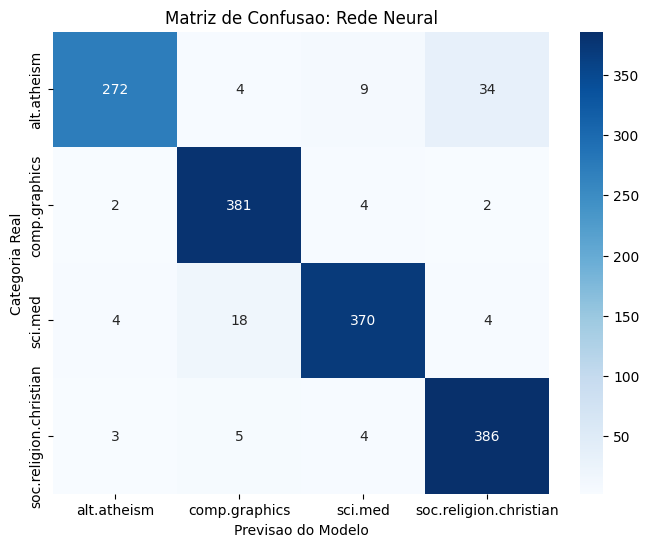

In [105]:
# Gerando a matriz numerica
cm = confusion_matrix(test_data.target, nn_predictions)

# Criando o grafico visual
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.target_names,
            yticklabels=test_data.target_names
            )
plt.xlabel('Previsao do Modelo')
plt.ylabel('Categoria Real')
plt.title('Matriz de Confusao: Rede Neural')
plt.show

# Analise de Erros

In [ ]:
# Criando um DataFrame com os resultados do teste
df_erros = pd.DataFrame({
    'Texto Original' : test_data.data,
    'Categoria Real' : [test_data.target_names[i] for i in test_data.target],
    'Previsao da Rede Neural' : [test_data.target_names[i] for i in nn_predictions],
})

# Para filtrar so onde o modelo errou
apenas_erros = df_erros[df_erros['Categoria Real'] != df_erros['Previsao da Rede Neural']]

print(f"Total de Erros: {len(apenas_erros)}")
# Ve os 5 primeiros erros que ele confundiu
print(apenas_erros.head())

Total de Erros: 93
                                       Texto Original Categoria Real  \
8   From: GWGREG01@ukcc.uky.edu\nSubject: Re: Preg...        sci.med   
15  From: swf@elsegundoca.ncr.com (Stan Friesen)\n...    alt.atheism   
19  From: mathew <mathew@mantis.co.uk>\nSubject: D...    alt.atheism   
26  From: UC512052@mizzou1.missouri.edu (David K. ...  comp.graphics   
36  Organization: Penn State University\nFrom: <RF...        sci.med   

   Previsao da Rede Neural  
8            comp.graphics  
15                 sci.med  
19  soc.religion.christian  
26                 sci.med  
36             alt.atheism  
